# Supersymmetric SU(2) matrix model: Final results

Notebook created by HLD for the work arXiv: 2503.13368 [quant-ph, hep-th]

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

# Data loading

In [13]:
def get_last_val(df):
    val_list = []
    name_list = []
    for i in range(len(df.columns)):
        lv = df[df.columns[i]].dropna().to_numpy()[-1]
        val_list.append(np.round(lv,5))
        name_list.append(df.columns[i])
    return name_list, val_list

def create_df_last_val(df_s, df_c, ll):
    ns1, vs1 = get_last_val(df_s)
    nc1, vc1 = get_last_val(df_c)
    df = pd.DataFrame({'name': ns1, 'cobyla_values': vc1, 'spsa_values': vs1})
    df.set_index('name', inplace = True)
    file_name = f'results/l{ll}_last_val_ev_op.csv'
    df.to_csv(file_name)
    print(f'file saved as {file_name}')
    return df


def load_drop(link, name = False):
    df = pd.read_csv(link)
    df.drop(['Unnamed: 0'], axis = 1, inplace=True)
    return df

def set_name_index(link):
    df = pd.read_csv(link)
    df.set_index('name', inplace=True)
    return df

In [7]:
df_02c= load_drop('results/L2_l02_op_ev_cobyla.csv')
df_05c= load_drop('results/L2_l05_op_ev_cobyla.csv')
df_10c =load_drop('results/L2_l10_op_ev_cobyla.csv')
df_20c= load_drop('results/L2_l20_op_ev_cobyla.csv')

df_02s= load_drop('results/L2_l02_op_ev_spsa_best.csv')
df_05s= load_drop('results/L2_l05_op_ev_spsa_best.csv')
df_10s= load_drop('results/L2_l10_op_ev_spsa_best.csv')
df_20s= load_drop('results/L2_l20_op_ev_spsa_best.csv')



# Plotting

In [61]:
def plot_e(df, ax, E, ll):
    ax.axhline(E, color = 'black', linestyle = 'dashed',  label = 'Exact energy')
    for i in range(len(df.columns)):
        ax.plot(np.arange(len(df[df.columns[i]])),df[df.columns[i]],color = color_list[i], 
                 label=df.columns[i])
    ax.set_title(f'$\lambda={ll}$, SPSA', fontsize = 15)
    ax.set_ylabel('Energy', fontsize = 14)
    ax.set_xlabel('Iterations', fontsize = 13)
    ax.legend()

In [9]:
E_02 = 0.003287
E_05 = 0.01690
E_10 = 0.04829
E_20 = 0.08385

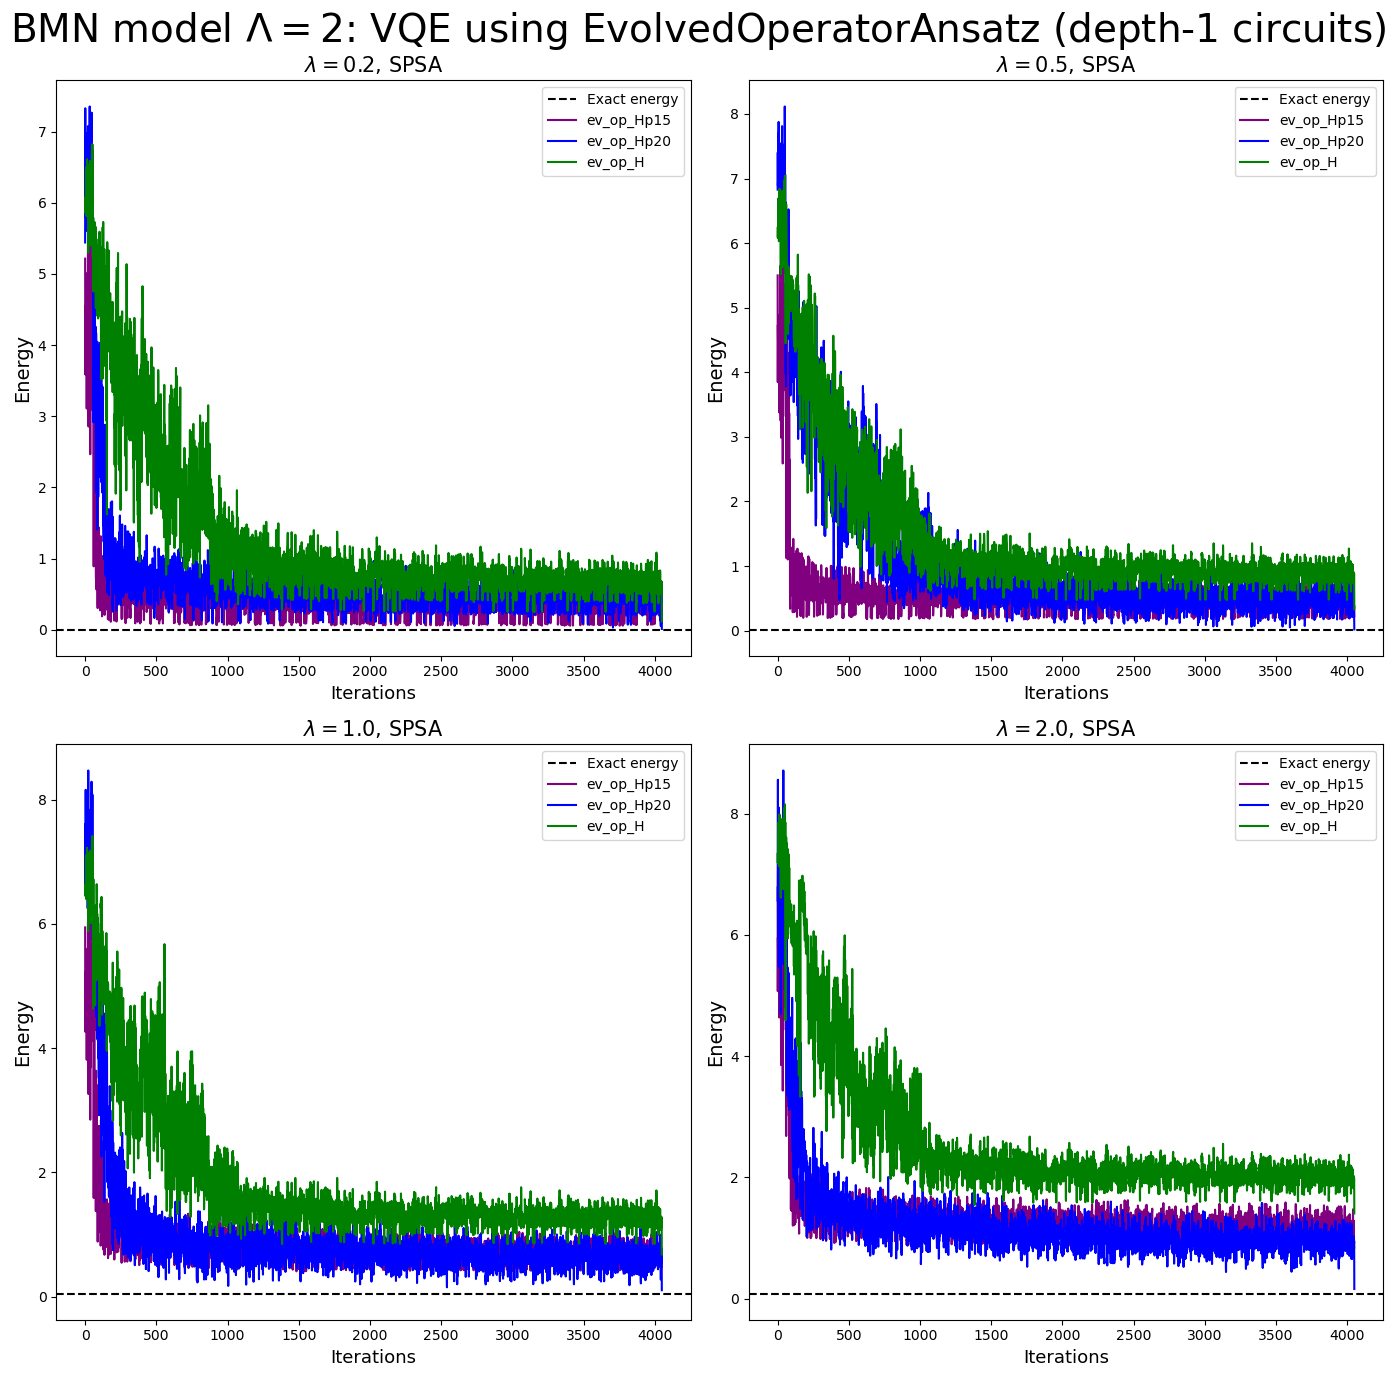

In [63]:
fig, ax = plt.subplots(2,2, figsize=(14,14), tight_layout = True)
color_list = ['purple', 'blue', 'green', 'orange', 'teal','pink', 
              'yellow', 'turquoise', 'brown', 'cyan','olive','magenta']
###################################
plot_e(df_02s[['ev_op_Hp15', 'ev_op_Hp20', 'ev_op_H']], ax[0,0], E_02, 0.2)
###################################
plot_e(df_05s[['ev_op_Hp15', 'ev_op_Hp20', 'ev_op_H']], ax[0,1], E_05, 0.5)
###################################
plot_e(df_10s[['ev_op_Hp15', 'ev_op_Hp20', 'ev_op_H']], ax[1,0], E_10, 1.0)
###################################
plot_e(df_20s[['ev_op_Hp15', 'ev_op_Hp20', 'ev_op_H']], ax[1,1], E_20, 2.0)
###################################
plt.suptitle('BMN model $\Lambda=2$: VQE using EvolvedOperatorAnsatz (depth-1 circuits)', fontsize = 28)
plt.savefig('L=2_BMN_ev_op_convergence_curves_spsa_1f.png')

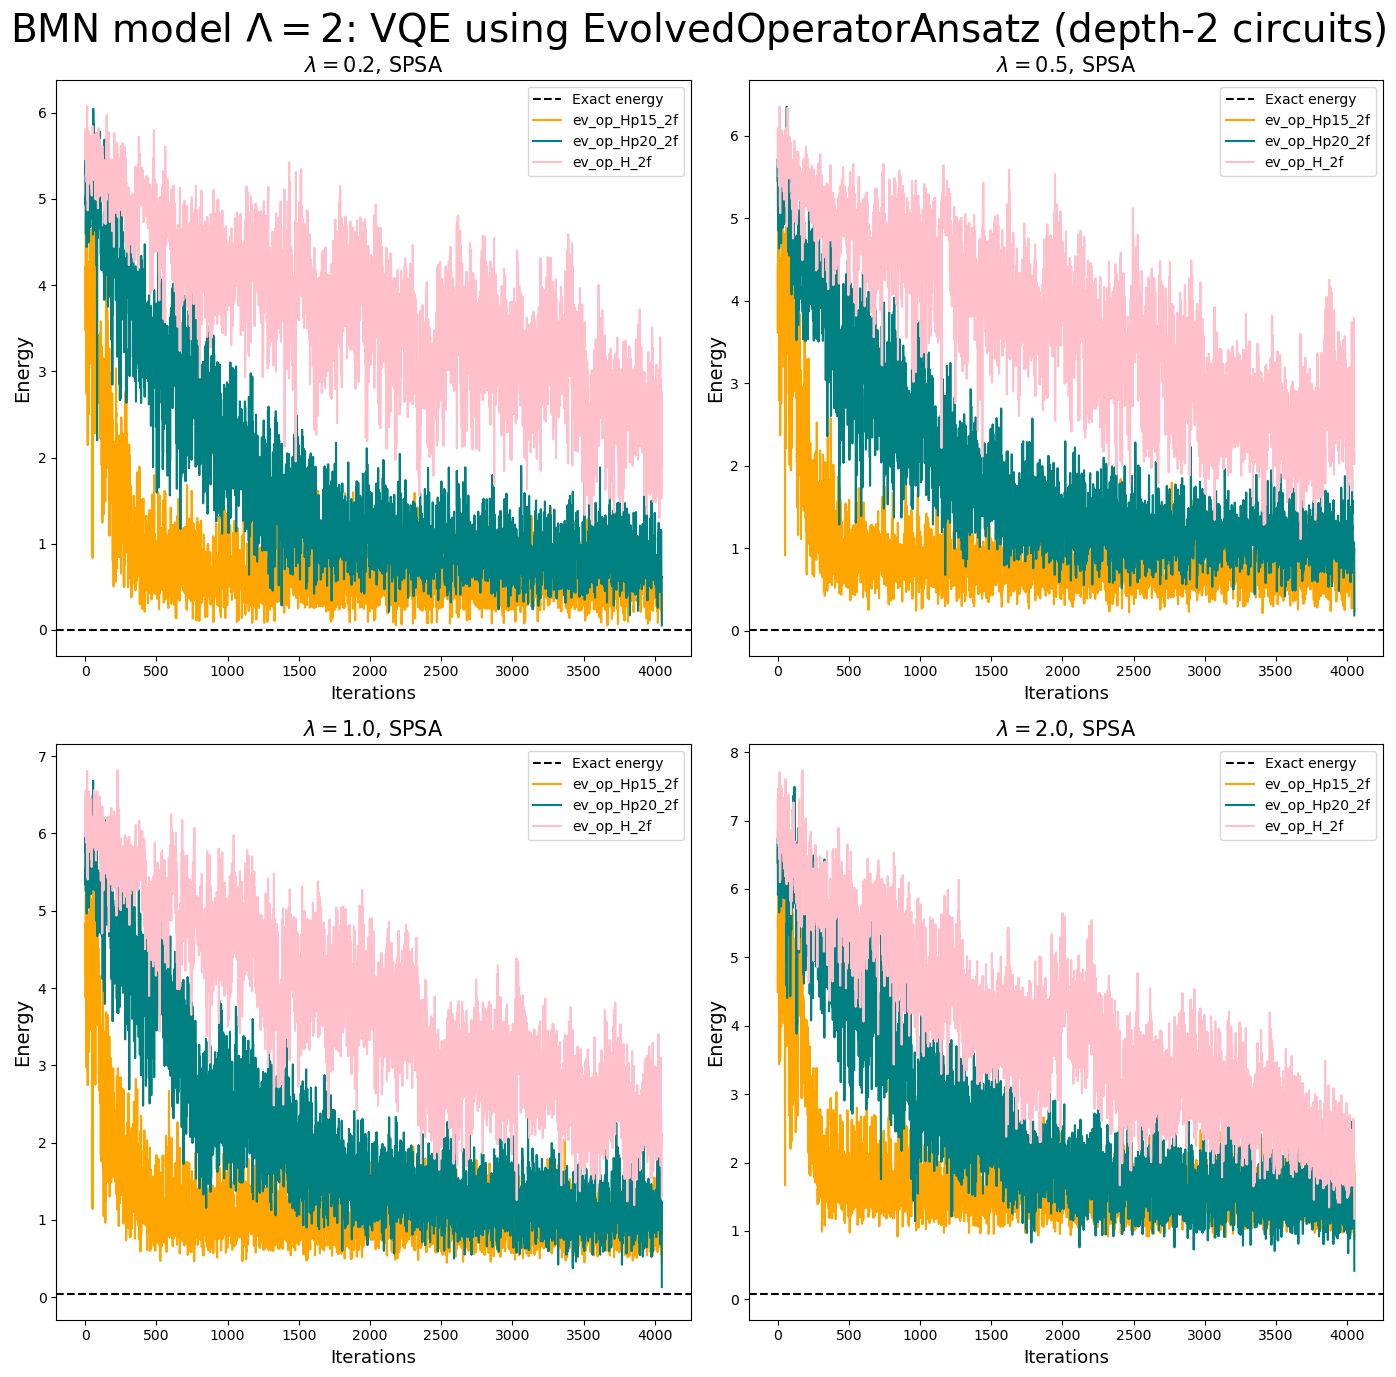

In [65]:
fig, ax = plt.subplots(2,2, figsize=(14,14), tight_layout = True)
color_list = ['orange', 'teal','pink', 
              'yellow', 'turquoise', 'brown', 'cyan','olive','magenta']
###################################
plot_e(df_02s[['ev_op_Hp15_2f', 'ev_op_Hp20_2f', 'ev_op_H_2f']], ax[0,0], E_02, 0.2)
###################################
plot_e(df_05s[['ev_op_Hp15_2f', 'ev_op_Hp20_2f', 'ev_op_H_2f']], ax[0,1], E_05, 0.5)
###################################
plot_e(df_10s[['ev_op_Hp15_2f', 'ev_op_Hp20_2f', 'ev_op_H_2f']], ax[1,0], E_10, 1.0)
###################################
plot_e(df_20s[['ev_op_Hp15_2f', 'ev_op_Hp20_2f', 'ev_op_H_2f']], ax[1,1], E_20, 2.0)
###################################
plt.suptitle('BMN model $\Lambda=2$: VQE using EvolvedOperatorAnsatz (depth-2 circuits)', fontsize = 28)
plt.savefig('L=2_BMN_ev_op_convergence_curves_spsa_2f.png')

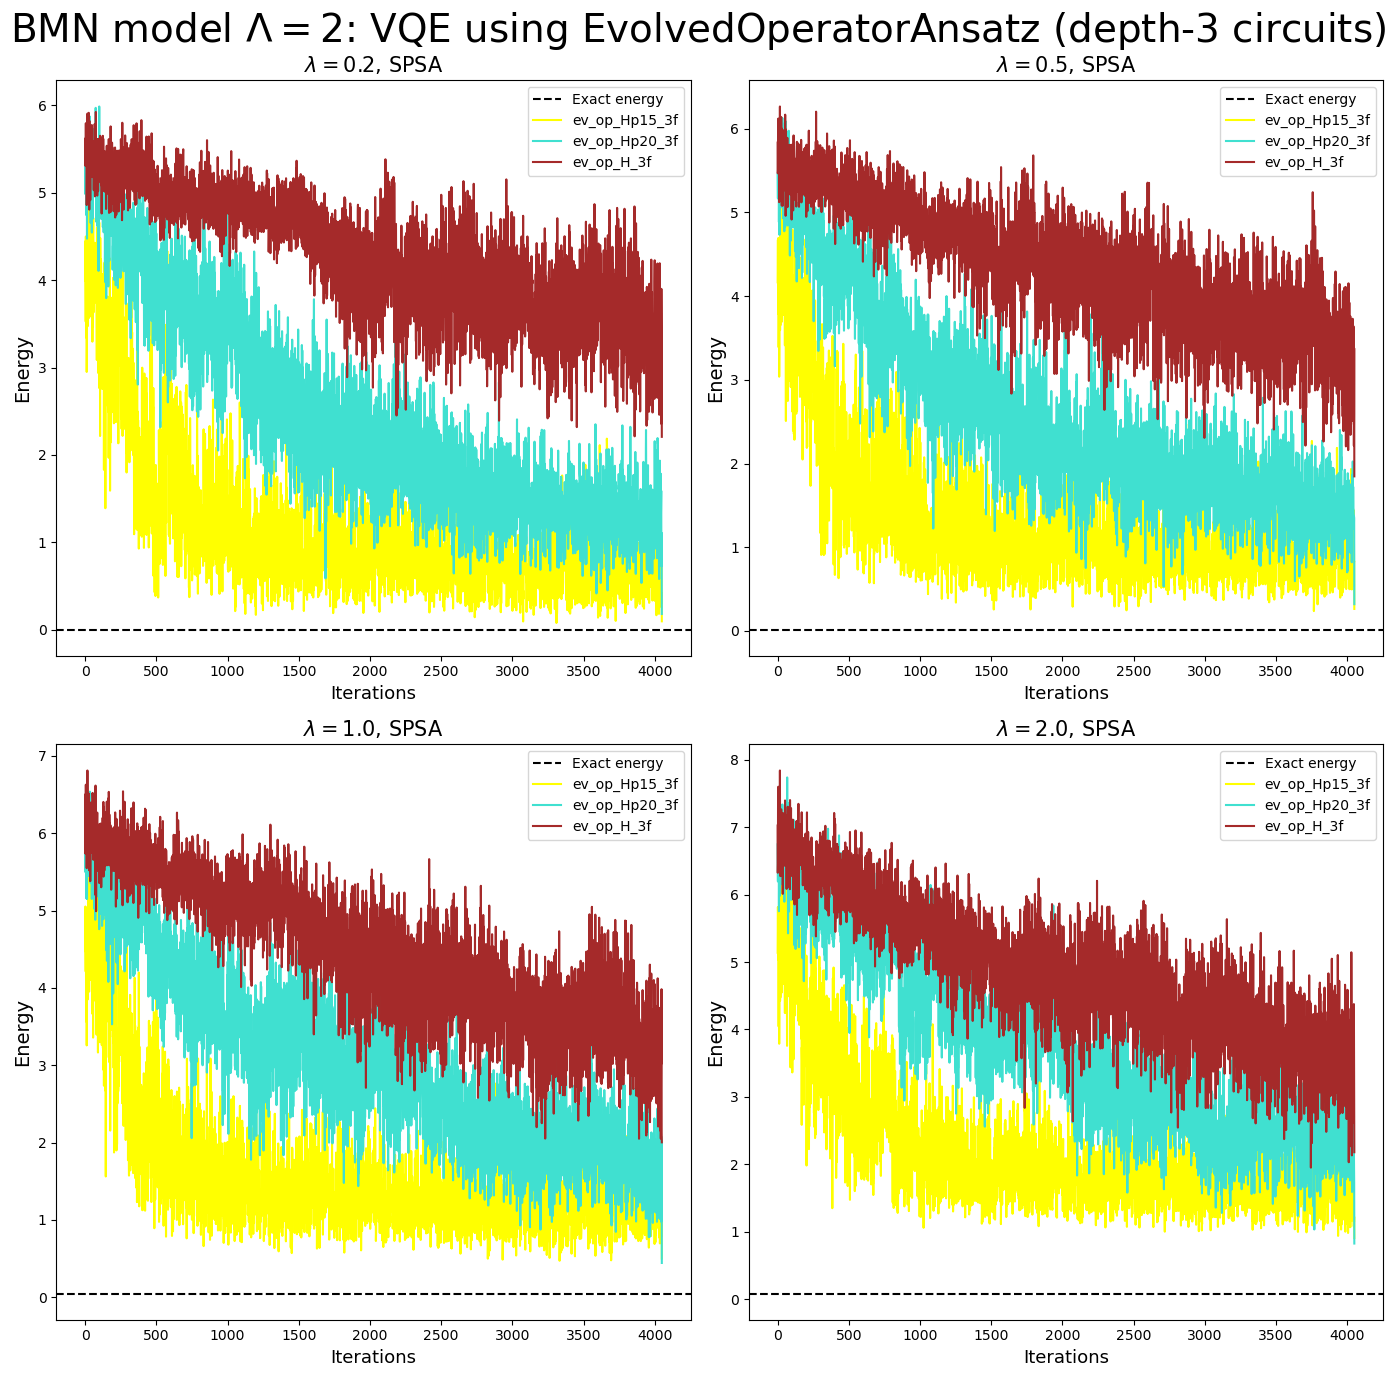

In [69]:
fig, ax = plt.subplots(2,2, figsize=(14,14), tight_layout = True)
color_list = ['yellow', 'turquoise', 'brown', 'cyan','olive','magenta']

###################################
plot_e(df_02s[['ev_op_Hp15_3f', 'ev_op_Hp20_3f', 'ev_op_H_3f']], ax[0,0], E_02, 0.2)
###################################
plot_e(df_05s[['ev_op_Hp15_3f', 'ev_op_Hp20_3f', 'ev_op_H_3f']], ax[0,1], E_05, 0.5)
###################################
plot_e(df_10s[['ev_op_Hp15_3f', 'ev_op_Hp20_3f', 'ev_op_H_3f']], ax[1,0], E_10, 1.0)
###################################
plot_e(df_20s[['ev_op_Hp15_3f', 'ev_op_Hp20_3f', 'ev_op_H_3f']], ax[1,1], E_20, 2.0)
###################################
plt.suptitle('BMN model $\Lambda=2$: VQE using EvolvedOperatorAnsatz (depth-3 circuits)', fontsize = 28)
plt.savefig('L=2_BMN_ev_op_convergence_curves_spsa_3f.png')

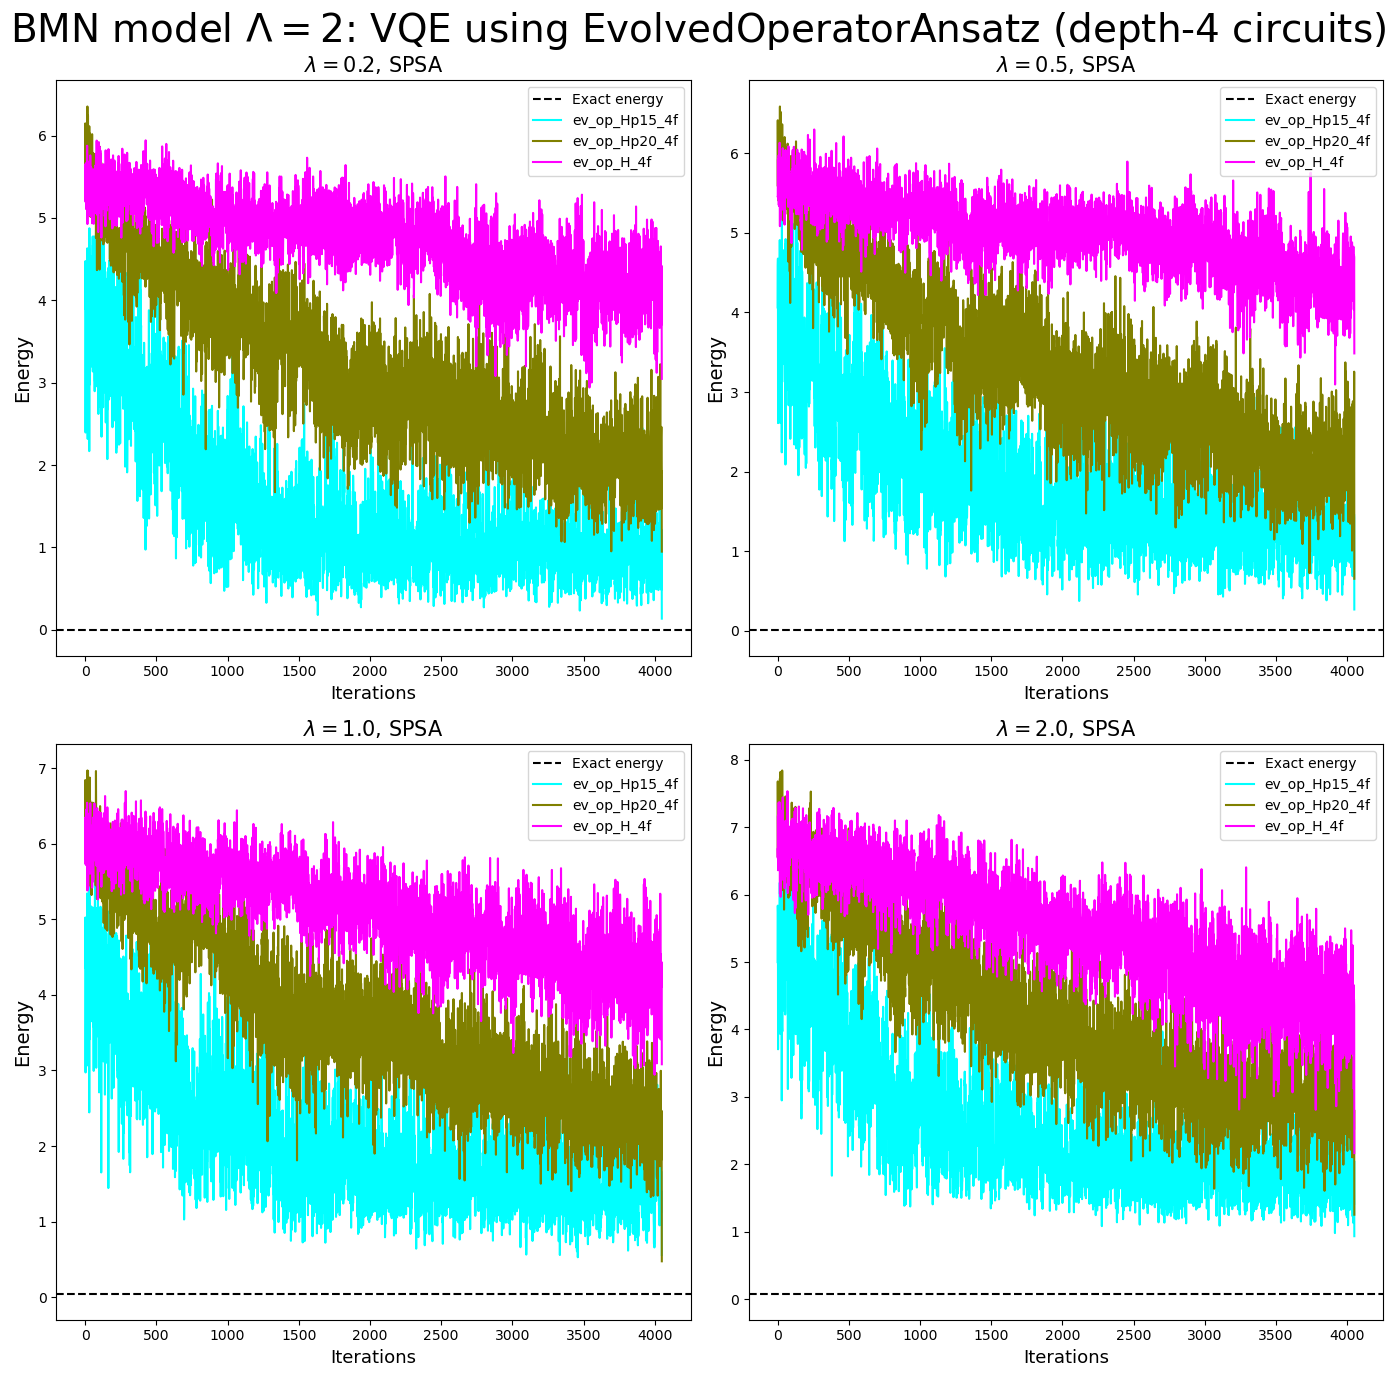

In [71]:
fig, ax = plt.subplots(2,2, figsize=(14,14), tight_layout = True)
color_list = ['cyan','olive','magenta']
###################################
plot_e(df_02s[['ev_op_Hp15_4f', 'ev_op_Hp20_4f', 'ev_op_H_4f']], ax[0,0], E_02, 0.2)
###################################
plot_e(df_05s[['ev_op_Hp15_4f', 'ev_op_Hp20_4f', 'ev_op_H_4f']], ax[0,1], E_05, 0.5)
###################################
plot_e(df_10s[['ev_op_Hp15_4f', 'ev_op_Hp20_4f', 'ev_op_H_4f']], ax[1,0], E_10, 1.0)
###################################
plot_e(df_20s[['ev_op_Hp15_4f', 'ev_op_Hp20_4f', 'ev_op_H_4f']], ax[1,1], E_20, 2.0)
###################################
plt.suptitle('BMN model $\Lambda=2$: VQE using EvolvedOperatorAnsatz (depth-4 circuits)', fontsize = 28)
plt.savefig('L=2_BMN_ev_op_convergence_curves_spsa_4f.png')

## COBYLA

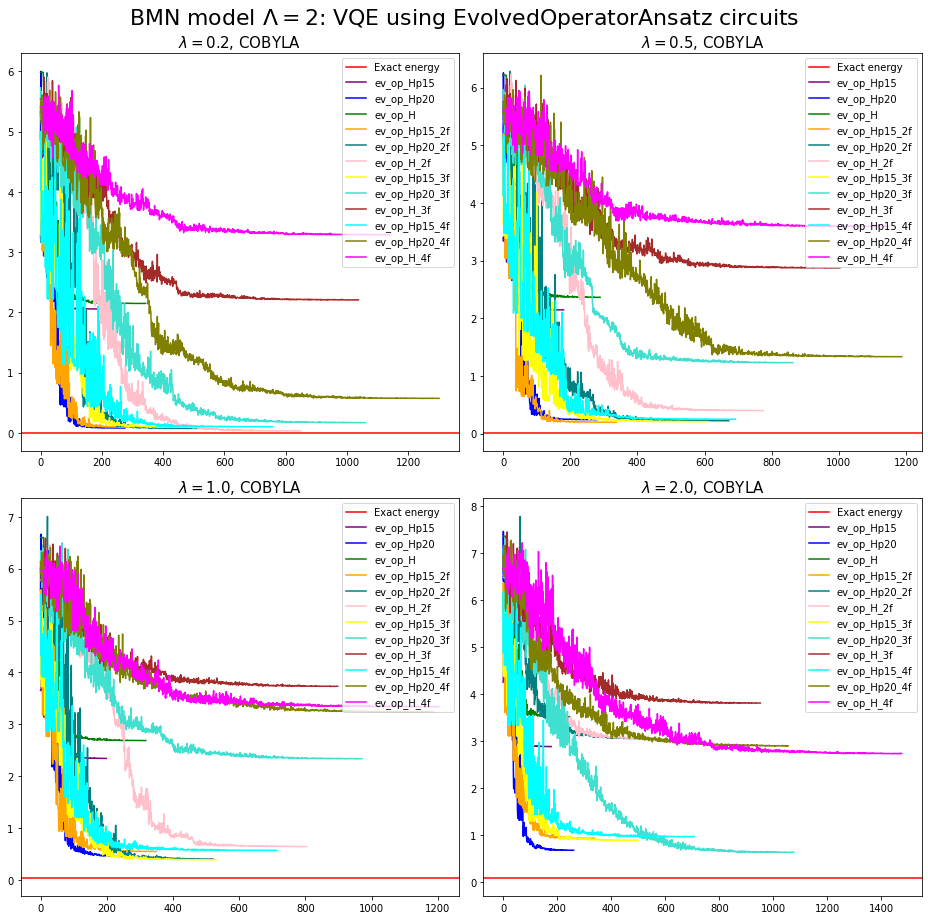

In [13]:
fig, ax = plt.subplots(2,2, figsize=(13,13), tight_layout = True)
color_list = ['purple', 'blue', 'green', 'orange', 'teal','pink', 
              'yellow', 'turquoise', 'brown', 'cyan','olive','magenta']
###################################
ax[0,0].axhline(E_02, color = 'red',  label = 'Exact energy')
plot_e(df_02c, ax[0,0])
ax[0,0].set_title('$\lambda=0.2$, COBYLA', fontsize = 15)
ax[0,0].legend()

###################################
ax[0,1].axhline(E_05, color = 'red',  label = 'Exact energy')
plot_e(df_05c, ax[0,1])
ax[0,1].set_title('$\lambda=0.5$, COBYLA', fontsize = 15)
ax[0,1].legend()

###################################
ax[1,0].axhline(E_10, color = 'red',  label = 'Exact energy')
plot_e(df_10c, ax[1,0])
ax[1,0].set_title('$\lambda=1.0$, COBYLA', fontsize = 15)
ax[1,0].legend()

###################################
ax[1,1].axhline(E_20, color = 'red',  label = 'Exact energy')
plot_e(df_20c, ax[1,1])
ax[1,1].set_title('$\lambda=2.0$, COBYLA', fontsize = 15)
ax[1,1].legend()

###################################
plt.suptitle('BMN model $\Lambda=2$: VQE using EvolvedOperatorAnsatz circuits', fontsize = 22)
plt.savefig('L=2_BMN_ev_op_convergence_curves_cobyla.png')

# Collate last values

In [17]:
df_l02= create_df_last_val(df_02s, df_02c, '02')
df_l02

file saved as results/l02_last_val_ev_op.csv


,cobyla_values,spsa_values
name,,
ev_op_Hp15,2.05509,0.09354
ev_op_Hp20,0.07807,0.01228
ev_op_H,2.14721,0.11827
ev_op_Hp15_2f,0.09291,0.09172
ev_op_Hp20_2f,0.07201,0.05251
ev_op_H_2f,0.03099,1.53414
ev_op_Hp15_3f,0.09358,0.09763
ev_op_Hp20_3f,0.16704,0.18184
ev_op_H_3f,2.20486,2.20766


In [19]:
df_l05= create_df_last_val(df_05s, df_05c, '05')
df_l05

file saved as results/l05_last_val_ev_op.csv


,cobyla_values,spsa_values
name,,
ev_op_Hp15,2.14404,0.22217
ev_op_Hp20,0.24023,0.01953
ev_op_H,2.36133,0.33105
ev_op_Hp15_2f,0.19482,0.23730
ev_op_Hp20_2f,0.22119,0.18799
ev_op_H_2f,0.39746,2.15186
ev_op_Hp15_3f,0.20605,0.26318
ev_op_Hp20_3f,1.22900,0.32031
ev_op_H_3f,2.87256,1.84668


In [21]:
df_l10= create_df_last_val(df_10s, df_10c, '10')
df_l10

file saved as results/l10_last_val_ev_op.csv


,cobyla_values,spsa_values
name,,
ev_op_Hp15,2.34535,0.47291
ev_op_Hp20,0.46279,0.10229
ev_op_H,2.69001,0.67807
ev_op_Hp15_2f,0.55453,0.44484
ev_op_Hp20_2f,0.40886,0.13280
ev_op_H_2f,0.64810,1.29156
ev_op_Hp15_3f,0.39722,0.50091
ev_op_Hp20_3f,2.34058,0.44396
ev_op_H_3f,3.73377,2.00362


In [23]:
df_l20= create_df_last_val(df_20s, df_20c, '20')
df_l20

file saved as results/l20_last_val_ev_op.csv


,cobyla_values,spsa_values
name,,
ev_op_Hp15,2.87744,0.87207
ev_op_Hp20,0.67041,0.15918
ev_op_H,3.51416,1.40527
ev_op_Hp15_2f,0.92383,0.88135
ev_op_Hp20_2f,3.04639,0.41748
ev_op_H_2f,3.05371,1.17822
ev_op_Hp15_3f,0.88379,0.90771
ev_op_Hp20_3f,0.62500,0.82568
ev_op_H_3f,3.80322,2.17969


# Find best ansatz

In [34]:
E_02 = 0.003287
E_05 = 0.01690
E_10 = 0.04829
E_20 = 0.08385
def find_best_ansatz(df, Ee):
    c_i = np.argmin(np.abs(df['cobyla_values']- Ee))
    print(f'Exact energy is {Ee}')
    print(f'Best ansatz for COBYLA is {df.index[c_i]} with value: {df.cobyla_values[c_i]}')
    s_i = np.argmin(np.abs(df['spsa_values']- Ee))
    print(f'Best ansatz for SPSA is {df.index[s_i]} with value: {df.spsa_values[s_i]}')
    diff_c = np.abs(df.cobyla_values[c_i]-Ee)
    diff_s = np.abs(df.spsa_values[s_i]-Ee)
    if diff_c < diff_s:
        print(f'Best ansatz overall is {df.index[c_i]}')
    if diff_c > diff_s:
         print(f'Best ansatz overall is {df.index[s_i]}')
    

In [32]:
df_l02 = set_name_index('results/l02_last_val_ev_op.csv')
df_l05 =set_name_index('results/l05_last_val_ev_op.csv')
df_l10 = set_name_index('results/l10_last_val_ev_op.csv')
df_l20 = set_name_index('results/l20_last_val_ev_op.csv')


In [36]:
find_best_ansatz(df_l02, E_02)

Exact energy is 0.003287
Best ansatz for COBYLA is ev_op_H_2f with value: 0.03099
Best ansatz for SPSA is ev_op_Hp20 with value: 0.01228
Best ansatz overall is ev_op_Hp20


In [38]:
find_best_ansatz(df_l05, E_05)

Exact energy is 0.0169
Best ansatz for COBYLA is ev_op_Hp15_2f with value: 0.19482
Best ansatz for SPSA is ev_op_Hp20 with value: 0.01953
Best ansatz overall is ev_op_Hp20


In [40]:
find_best_ansatz(df_l10, E_10)

Exact energy is 0.04829
Best ansatz for COBYLA is ev_op_Hp15_3f with value: 0.39722
Best ansatz for SPSA is ev_op_Hp20 with value: 0.10229
Best ansatz overall is ev_op_Hp20


In [42]:
find_best_ansatz(df_l20, E_20)

Exact energy is 0.08385
Best ansatz for COBYLA is ev_op_Hp20_3f with value: 0.625
Best ansatz for SPSA is ev_op_Hp20 with value: 0.15918
Best ansatz overall is ev_op_Hp20


# Plot last values

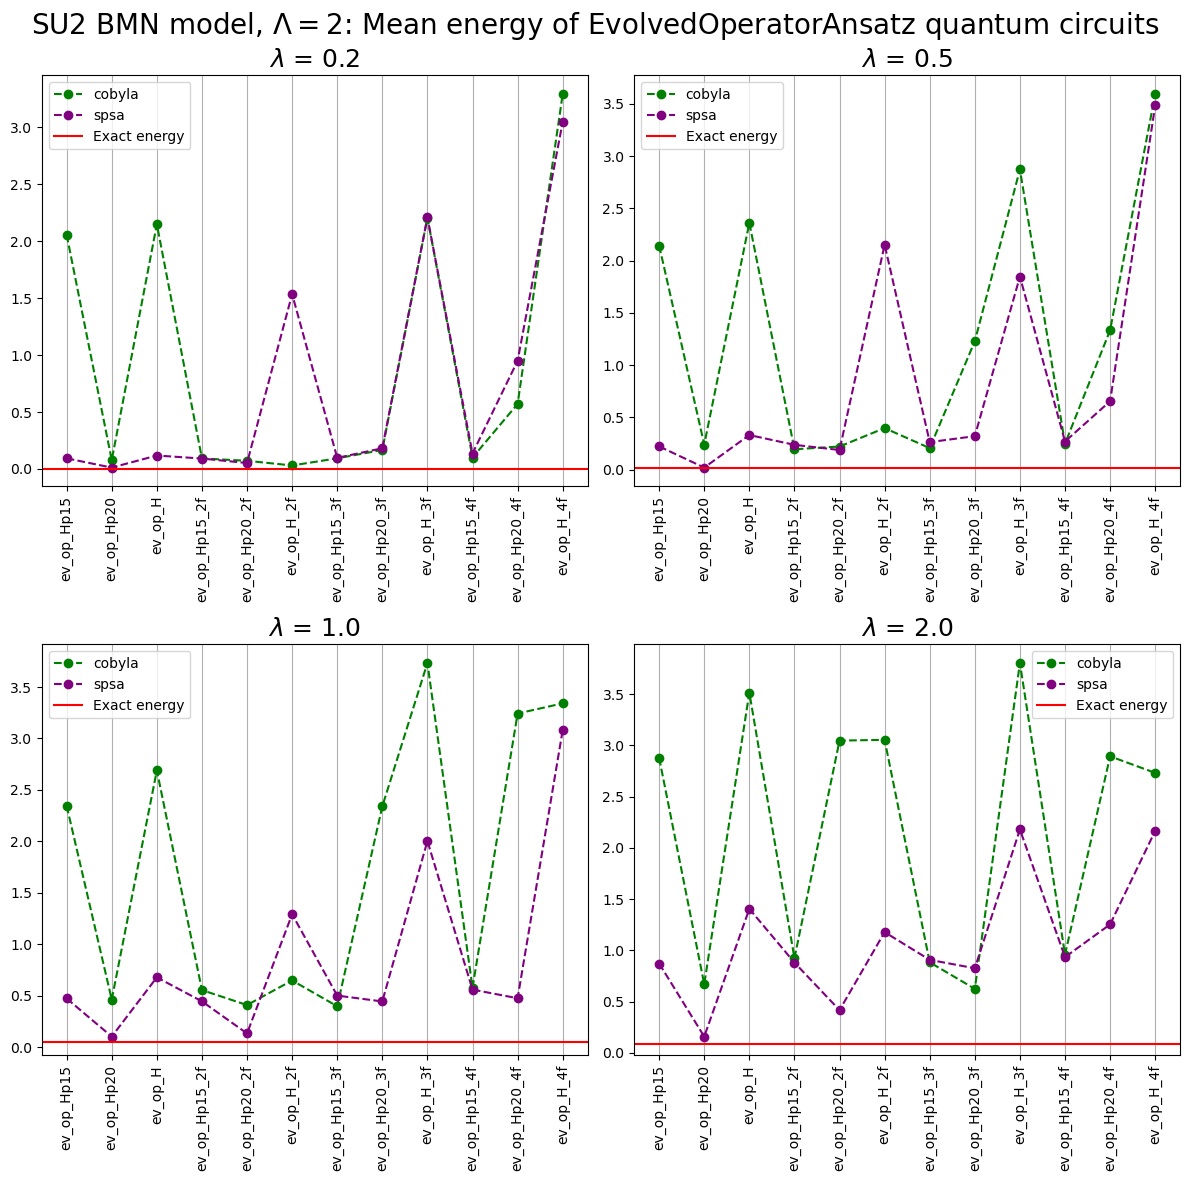

In [45]:
fig, ax = plt.subplots(2,2, figsize = (12,12), tight_layout= True)
ax[0,0].plot(df_l02['cobyla_values'], color='green', marker='o', linestyle='dashed', label='cobyla')
ax[0,0].plot(df_l02['spsa_values'], color='purple', marker='o', linestyle='dashed', label = 'spsa')
ax[0,0].axhline(E_02, color = 'red', label='Exact energy')
for tick in ax[0,0].get_xticklabels():
    tick.set_rotation(90)
ax[0,0].set_title('$\lambda$ = 0.2', fontsize = 18)
ax[0,0].legend()
ax[0,0].xaxis.grid(True)


ax[0,1].plot(df_l05['cobyla_values'],  color='green', marker='o', linestyle='dashed',label='cobyla')
ax[0,1].plot(df_l05['spsa_values'],  color='purple', marker='o', linestyle='dashed',label = 'spsa')
ax[0,1].axhline(E_05, color = 'red', label='Exact energy')
for tick in ax[0,1].get_xticklabels():
    tick.set_rotation(90)
ax[0,1].set_title('$\lambda$ = 0.5', fontsize = 18)
#ax[0,1].set_ylim([3.35, 3.42])
ax[0,1].xaxis.grid(True)
ax[0,1].legend()

ax[1,0].plot(df_l10['cobyla_values'],  color='green', marker='o', linestyle='dashed',label='cobyla')
ax[1,0].plot(df_l10['spsa_values'],  color='purple', marker='o', linestyle='dashed',label = 'spsa')
ax[1,0].axhline(E_10, color = 'red', label='Exact energy')
for tick in ax[1,0].get_xticklabels():
    tick.set_rotation(90)
ax[1,0].set_title('$\lambda$ = 1.0', fontsize = 18)
ax[1,0].xaxis.grid(True)
ax[1,0].legend()

ax[1,1].plot(df_l20['cobyla_values'],  color='green', marker='o', linestyle='dashed',label='cobyla')
ax[1,1].plot(df_l20['spsa_values'],  color='purple', marker='o', linestyle='dashed',label = 'spsa')
ax[1,1].axhline(E_20, color = 'red', label='Exact energy')
for tick in ax[1,1].get_xticklabels():
    tick.set_rotation(90)
ax[1,1].set_title('$\lambda$ = 2.0', fontsize = 18)
ax[1,1].xaxis.grid(True)
ax[1,1].legend(loc = 'upper right')

plt.suptitle('SU2 BMN model, $\Lambda=2$: Mean energy of EvolvedOperatorAnsatz quantum circuits', fontsize = 20)
plt.savefig('L=2_BMN_ev_op_ansatze.png')